EPSG:4326


/usr/local/lib/python3.8/dist-packages/geopandas/geodataframe.py:1538: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/usr/local/lib/python3.8/dist-packages/geopandas/geodataframe.py:1538: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/usr/local/lib/python3.8/dist-packages/geopandas/geodataframe.py:1538: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining a

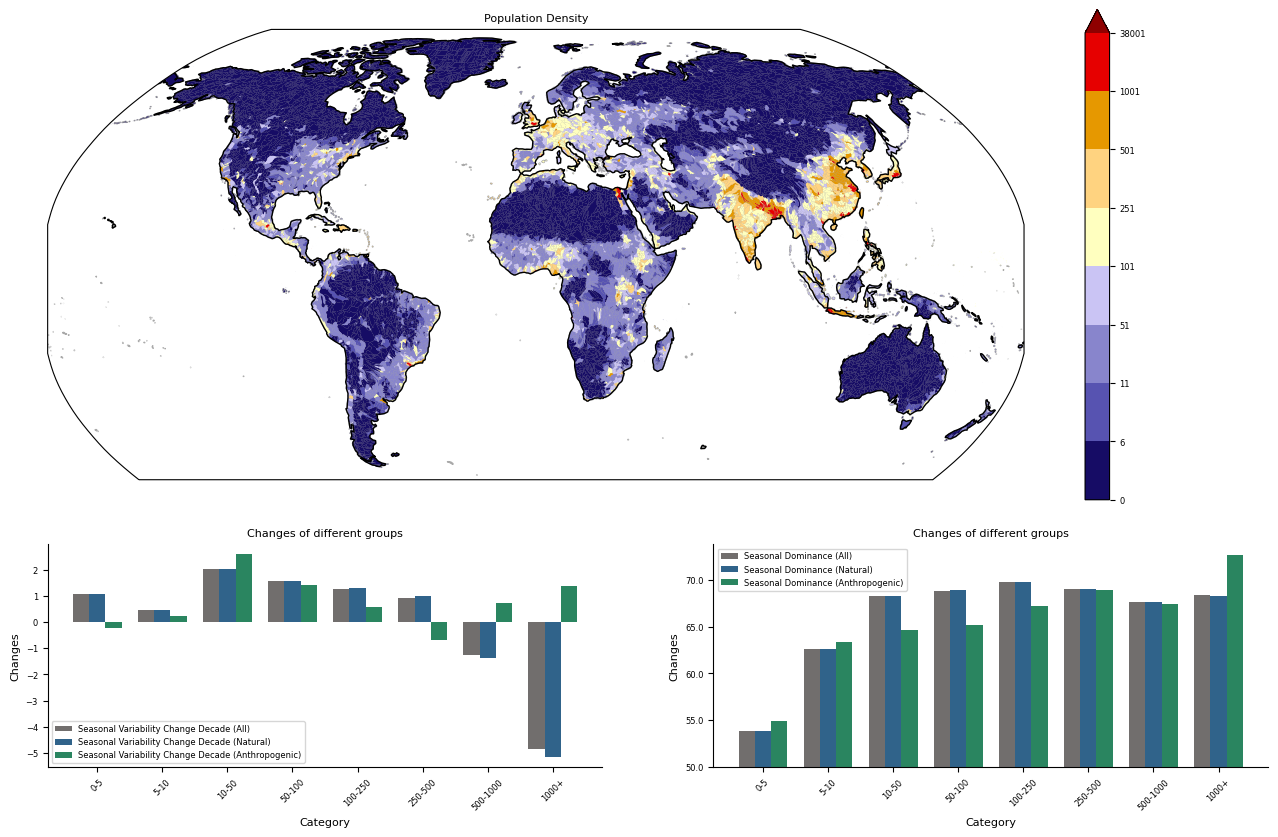

In [2]:
import sys
sys.path.append('../../my_spatial_analyze/data_analyze/basin_wise_analysis')
sys.path.append('../../my_spatial_analyze/data_analyze/correlation_analysis')
sys.path.append('../../my_spatial_analyze/')
import visualization
import correlation_plots
import basin_wise_analysis
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
import geopandas as gpd
import numpy as np
from datetime import datetime
from dateutil.relativedelta import relativedelta
from matplotlib.colors import ListedColormap


# make pdf editable in adobe illustrator
mpl.rcParams['pdf.fonttype'] = 42

lake_lse_pkl_path = '/data/v2/lake_lse_gdf_for_figure_making.pkl'
basinsatlas_pkl_path = '/data/v2/BasinATLAS_v10_lev06.pkl'

#lake_lse_gdf = pd.read_pickle(lake_lse_pkl_path)
basinatlas_gdf = pd.read_pickle(basinsatlas_pkl_path)
basinatlas_gdf.geometry = basinatlas_gdf.geometry.simplify(0.01)
print(basinatlas_gdf.crs)

ax_mosaic = """
    cc
    cc
    ab
"""

per_subplot_kw = {
    'c': {'projection': ccrs.Robinson()},
}

fig, axs = plt.subplot_mosaic(
    ax_mosaic,
    figsize=(400/25.4, 250/25.4),
    per_subplot_kw=per_subplot_kw
)

colors_for_population_density = [
    '#160C65', '#5753B1', '#8885CC', '#CAC4F4', '#FFFFBF', '#FFD380', '#E69800', '#E60000', '#8F0000'
]
cmap_for_population_density = ListedColormap(colors_for_population_density)

ax, sm = visualization.plot_grid(
    grid_gdf=basinatlas_gdf,
    color_column='ppd_pk_sav',
    title='Population Density',
    use_discrete_color=True,
    discrete_bins=[0, 6, 11, 51, 101, 251, 501, 1001, 38001],
    cmap=cmap_for_population_density,
    edgecolor='none',
    add_rivers=False,
    projection=ccrs.Geodetic(),
    extent=[-180, -60, 180, 90],
    set_global=False,
    gridlines=False,
    return_colorbar_sm=True,
    cbar_extend='max',
    ax=axs['c'],
    fix_for_antimeridian=False
)
lake_lse_gdf = pd.read_pickle(lake_lse_pkl_path)

lake_lse_gdf['linear_trend_of_standard_deviation_percentage_per_period'] = lake_lse_gdf['linear_trend_of_standard_deviation_percentage_per_period'] * 10
lake_lse_gdf['linear_trend_of_standard_deviation_percentage_per_period_natural'] = lake_lse_gdf.apply(lambda row: row['linear_trend_of_standard_deviation_percentage_per_period'] if row['Lake_type'] == 1 else np.nan, axis=1)
lake_lse_gdf['linear_trend_of_standard_deviation_percentage_per_period_anthropogenic'] = lake_lse_gdf.apply(lambda row: row['linear_trend_of_standard_deviation_percentage_per_period'] if row['Lake_type'] != 1 else np.nan, axis=1)
to_plot_column_names = [
    'linear_trend_of_standard_deviation_percentage_per_period',
    'linear_trend_of_standard_deviation_percentage_per_period_natural',
    'linear_trend_of_standard_deviation_percentage_per_period_anthropogenic'
]
to_plot_column_labels = [
    'Seasonal Variability Change Decade (All)',
    'Seasonal Variability Change Decade (Natural)',
    'Seasonal Variability Change Decade (Anthropogenic)'
]
to_plot_column_colors = [
    '#716e6d',
    '#30638a',
    '#2a8560'
]
agg_to_bar_stat_types = [
    'median',
    'median',
    'median'
]

to_group_by_column_name = 'ppd_pk_sav'
group_bins = [0, 5, 10, 50, 100, 250, 500, 1000, np.inf]
group_labels = ['0-5', '5-10', '10-50', '50-100', '100-250', '250-500', '500-1000', '1000+']

correlation_plots.bar_plot_of_different_groups(
    to_plot_df=lake_lse_gdf,
    to_plot_column_names=to_plot_column_names,
    to_plot_column_colors=to_plot_column_colors,
    to_plot_column_labels=to_plot_column_labels,
    agg_to_bar_stat_types=agg_to_bar_stat_types,
    to_group_by_column_name=to_group_by_column_name,
    group_bins=group_bins,
    group_labels=group_labels,
    bar_width=0.25,
    xticklabel_rotation=45,
    ax=axs['a'],
    show_plot=False
)
del lake_lse_gdf

lake_lse_gdf = pd.read_pickle(lake_lse_pkl_path)
lake_lse_gdf['seasonality_dominance_percentage'] = lake_lse_gdf['seasonality_dominance_percentage'] - 50
lake_lse_gdf['seasonality_dominance_percentage_natural'] = lake_lse_gdf.apply(lambda row: row['seasonality_dominance_percentage'] if row['Lake_type'] == 1 else np.nan, axis=1)
lake_lse_gdf['seasonality_dominance_percentage_anthropogenic'] = lake_lse_gdf.apply(lambda row: row['seasonality_dominance_percentage'] if row['Lake_type'] != 1 else np.nan, axis=1)
to_plot_column_names = [
    'seasonality_dominance_percentage',
    'seasonality_dominance_percentage_natural',
    'seasonality_dominance_percentage_anthropogenic'
]
to_plot_column_labels = [
    'Seasonal Dominance (All)',
    'Seasonal Dominance (Natural)',
    'Seasonal Dominance (Anthropogenic)'
]
to_plot_column_colors = [
    '#716e6d',
    '#30638a',
    '#2a8560'
]
agg_to_bar_stat_types = [
    'median',
    'median',
    'median'
]

to_group_by_column_name = 'ppd_pk_sav'
group_bins = [0, 5, 10, 50, 100, 250, 500, 1000, np.inf]
group_labels = ['0-5', '5-10', '10-50', '50-100', '100-250', '250-500', '500-1000', '1000+']

correlation_plots.bar_plot_of_different_groups(
    to_plot_df=lake_lse_gdf,
    to_plot_column_names=to_plot_column_names,
    to_plot_column_colors=to_plot_column_colors,
    to_plot_column_labels=to_plot_column_labels,
    agg_to_bar_stat_types=agg_to_bar_stat_types,
    to_group_by_column_name=to_group_by_column_name,
    group_bins=group_bins,
    group_labels=group_labels,
    bar_width=0.25,
    xticklabel_rotation=45,
    ax=axs['b'],
    show_plot=False
)
# have all y ticklabels plus 50
axs['b'].set_yticklabels([f'{tick + 50}' for tick in axs['b'].get_yticks()])

#save_to_pdf
plt.savefig('/results/Ext_Data_Fig_5_raw.pdf', bbox_inches='tight')
